In [1]:
import numpy as np
from matplotlib import pyplot as plt
import random as random
from time import time
from sklearn.model_selection import train_test_split
import umap
import pandas as pd
from sklearn.decomposition import PCA
from statsmodels.tsa.stattools import adfuller
from sklearn.manifold import TSNE

I0000 00:00:1776383669.530016    1409 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776383672.042231    1409 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776383680.733523    1409 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
def make_covar_stationary(data):
    d_best = 0

    # increase difference untill covaraince stationary
    while True:

        # adfuller method uses hypothesis test to see if data is covaraince stationary
        p_value = adfuller(data)[1]

        if p_value < 0.05:
            # it is likely covariance stationary
            return d_best, data
        
        else:
            # not covaraince stationary do increase d by 1
            d_best += 1
            data = np.diff(data, n=d_best)

In [3]:
df = pd.read_csv("cleaned_produce.csv")

In [4]:
products = pd.unique(df["productname"])

In [5]:
city_cols = ['atlantaretail', 'losangelesretail', 'newyorkretail', 'chicagoretail']
average_prices = []
first = True
for product in products:
    temp = df[df["productname"] == product]
    if first:
        month_labels = pd.to_datetime(temp['date']).dt.month
        first = False
    average_price = temp[city_cols].mean(axis=1)
    average_prices.append(average_price)
average_prices = np.array(average_prices)

In [6]:
print(average_prices.shape)

(22, 1019)


In [ ]:
temp = pd.DataFrame({product:average_prices[i] for i, product in zip(np.arange(22), products)})
detrended_price_data = []
for i, product in enumerate(products):
    # get dfference order and covar stationaed data
    d, produce_data = make_covar_stationary(temp[product].values)
    print(product, len(produce_data))
    if len(produce_data) == 1019:
        produce_data = produce_data[:-1]
    detrended_price_data.append(produce_data)
detrended_price_data = np.array(detrended_price_data)

Asparagus 1019
Avocados 1019
Broccoli Bunches 1018
Broccoli Crowns 1019
Cantaloupe 1018
Carrots 1018
Cauliflower 1018
Celery 1019
Flame Grapes 1019
Green Leaf Lettuce 1019
Honeydews 1018
Iceberg Lettuce 1019
Nectarines 1019
Oranges 1018
Peaches 1019
Plums 1019
Potatoes 1018
Red Leaf Lettuce 1019
Romaine Lettuce 1019
Strawberries 1019
Thompson Grapes 1019
Tomatoes 1019


In [8]:
print(detrended_price_data.shape)

(22, 1018)


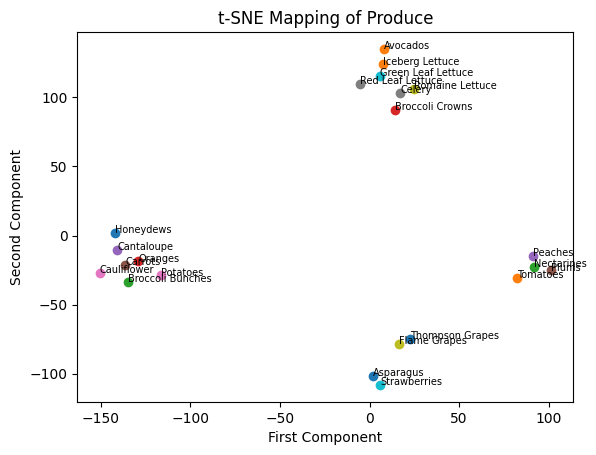

In [9]:
start = time()
tsne = TSNE(2, perplexity=2)
projected = tsne.fit_transform(detrended_price_data)
# Plot results using different colors for each cluster
for y, label in zip(projected, products):
    plt.scatter(y[0], y[1])
    plt.annotate(label, (y[0], y[1]), fontsize=7)
plt.title("t-SNE Mapping of Produce")
plt.xlabel("First Component")
plt.ylabel("Second Component")
umap_time = time() - start

In [10]:
group5 = detrended_price_data[[10, 5, 4, 2, 6, 13, 16]]

In [11]:
start = time()
tsne2 = TSNE(2, perplexity=20)
projected2 = tsne2.fit_transform(group5.T)
# Plot results using different colors for each cluster
# for y, label in zip(projected, products):
#     plt.scatter(y[0], y[1])
#     plt.annotate(label, (y[0], y[1]), fontsize=7)
# plt.title("t-SNE Mapping of Seasons")
# plt.xlabel("First Component")
# plt.ylabel("Second Component")
umap_time = time() - start

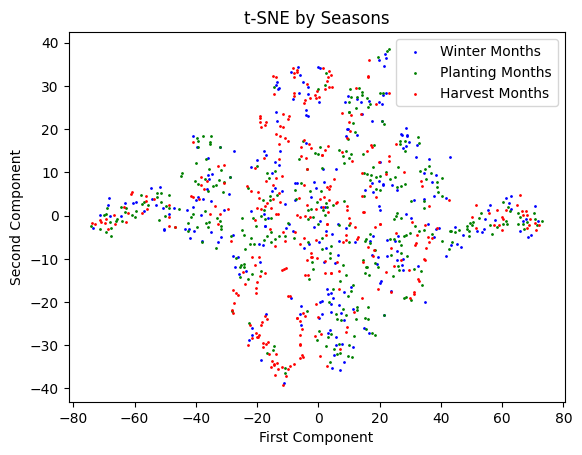

In [12]:
mask1 = (month_labels == 0) | (month_labels == 1) | (month_labels == 10) | (month_labels == 11)
mask2 = (month_labels == 2) | (month_labels == 3) | (month_labels == 4) | (month_labels == 5)
mask3 = (month_labels == 6) | (month_labels == 7) | (month_labels == 8) | (month_labels == 9)
n1 = np.sum(mask1)
n2 = np.sum(mask2)
n3 = np.sum(mask3)
# n4 = np.sum(mask4)
# n5 = np.sum(mask5)
# n6 = np.sum(mask6)
# n7 = np.sum(mask7)
# n8 = np.sum(mask8)
# n9 = np.sum(mask9)
# n10 = np.sum(mask10)
# n11 = np.sum(mask11)
# n12 = np.sum(mask12)
plt.title("t-SNE by Seasons")
plt.xlabel("First Component")
plt.ylabel("Second Component")
plt.scatter(projected2[mask1[:-1], 0], projected2[mask1[:-1], 1], c='b', s=1, label="Winter Months")
plt.scatter(projected2[mask2[:-1], 0], projected2[mask2[:-1], 1], c='g', s=1, label="Planting Months")
plt.scatter(projected2[mask3[:-1], 0], projected2[mask3[:-1], 1], c='r', s=1, label="Harvest Months")
plt.legend()

In [13]:
print("Begin Training UMAP")
# Perform UMAP
start = time()
u3 = umap.UMAP()
reduced = u3.fit_transform(detrended_price_data)
umap_time = time() - start

print(f"Time for UMAP: {umap_time}")

Begin Training UMAP
Time for UMAP: 16.80561137199402


Text(0, 0.5, 'Second Component')

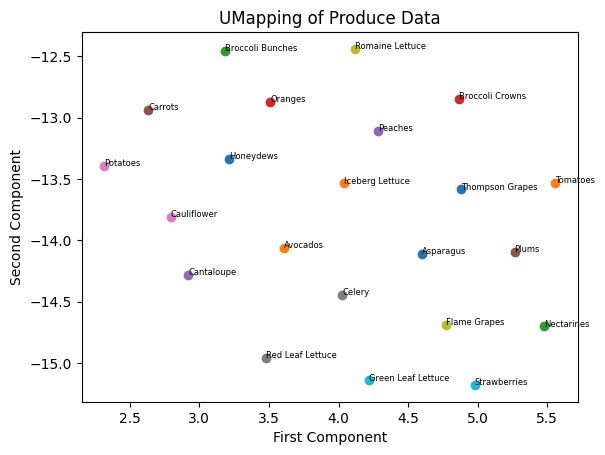

In [14]:
plt.title("UMapping of Produce Data")
for y, label in zip(reduced, products):
    plt.scatter(y[0], y[1])
    plt.annotate(label, (y[0], y[1]), fontsize=6)
# plt.scatter(reduced[:, 0], reduced[:, 1])
plt.xlabel("First Component")
plt.ylabel("Second Component")

In [15]:
print("Begin Training UMAP")
# Perform UMAP
start = time()
u = umap.UMAP()
projected = u.fit_transform(detrended_price_data.T)
umap_time = time() - start

print(f"Time for UMAP: {umap_time}")

Begin Training UMAP
Time for UMAP: 1.8374242782592773


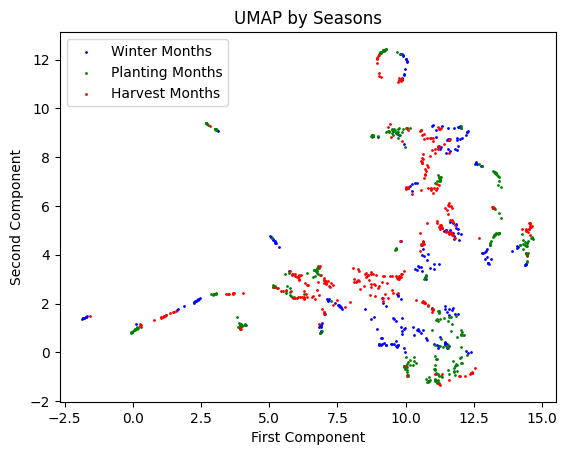

In [16]:
# Plot t-SNE and UMAP results
mask1 = (month_labels == 0) | (month_labels == 1) | (month_labels == 10) | (month_labels == 11)
mask2 = (month_labels == 2) | (month_labels == 3) | (month_labels == 4) | (month_labels == 5)
mask3 = (month_labels == 6) | (month_labels == 7) | (month_labels == 8) | (month_labels == 9)
n1 = np.sum(mask1)
n2 = np.sum(mask2)
n3 = np.sum(mask3)
# n4 = np.sum(mask4)
# n5 = np.sum(mask5)
# n6 = np.sum(mask6)
# n7 = np.sum(mask7)
# n8 = np.sum(mask8)
# n9 = np.sum(mask9)
# n10 = np.sum(mask10)
# n11 = np.sum(mask11)
# n12 = np.sum(mask12)
plt.title("UMAP by Seasons")
plt.scatter(projected[mask1[:-1], 0], projected[mask1[:-1], 1], c='b', s=1, label="Winter Months")
plt.scatter(projected[mask2[:-1], 0], projected[mask2[:-1], 1], c='g', s=1, label="Planting Months")
plt.scatter(projected[mask3[:-1], 0], projected[mask3[:-1], 1], c='r', s=1, label="Harvest Months")
# plt.scatter(projected[mask2, 0], projected[mask2, 1], c=[2]*n2, s=1, label=2)
# plt.scatter(projected[mask3, 0], projected[mask3, 1], c=[3]*n3, s=1, label=3)
# plt.scatter(projected[mask4, 0], projected[mask4, 1], c=[4]*n4, s=1, label=4)
# plt.scatter(projected[mask5, 0], projected[mask5, 1], c=[5]*n5, s=1, label=5)
# plt.scatter(projected[mask6, 0], projected[mask6, 1], c=[6]*n6, s=1, label=6)
# plt.scatter(projected[mask7, 0], projected[mask7, 1], c=[7]*n7, s=1, label=7)
# plt.scatter(projected[mask8, 0], projected[mask8, 1], c=[8]*n8, s=1, label=8)
# plt.scatter(projected[mask9, 0], projected[mask9, 1], c=[9]*n9, s=1, label=9)
# plt.scatter(projected[mask10, 0], projected[mask10, 1], c=[10]*n10, s=1, label=10)
# plt.scatter(projected[mask11, 0], projected[mask11, 1], c=[11]*n11, s=1, label=11)
# plt.scatter(projected[mask12, 0], projected[mask12, 1], c=[12]*n12, s=1, label=12)
plt.xlabel("First Component")
plt.ylabel("Second Component")
plt.legend()
plt.show()

In [21]:
data_prices = []
labels = []
for product in products:
    for i, city in enumerate(city_cols):
        temp = df[df["productname"] == product]
        data_prices.append(temp[city])
        labels.append(i % 4)

data_prices = np.array(data_prices)
print(data_prices.shape)

(88, 1019)


In [22]:
labels = np.array(labels)

In [23]:
print("Begin Training UMAP")
# Perform UMAP
start = time()
u2 = umap.UMAP()
projected2 = u2.fit_transform(data_prices)
umap_time = time() - start

print(f"Time for UMAP: {umap_time}")

Begin Training UMAP
Time for UMAP: 0.40354323387145996


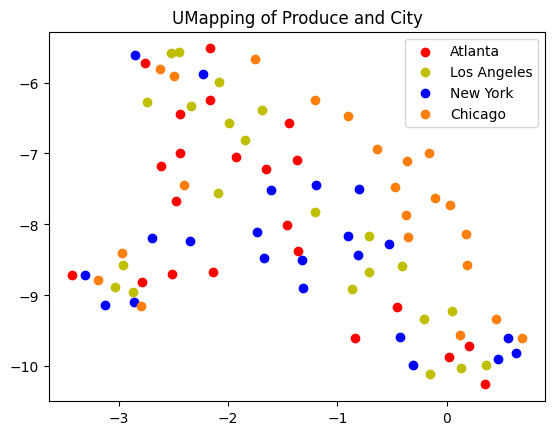

In [24]:
mask1 = labels == 0
mask2 = labels == 1
mask3 = labels == 2
mask4 = labels == 3
plt.title("UMapping of Produce and City")
plt.scatter(projected2[mask1, 0], projected2[mask1, 1], c='r', label="Atlanta")
plt.scatter(projected2[mask2, 0], projected2[mask2, 1], c='y', label="Los Angeles")
plt.scatter(projected2[mask3, 0], projected2[mask3, 1], c='b', label="New York")
plt.scatter(projected2[mask4, 0], projected2[mask4, 1], c='tab:orange', label="Chicago")

plt.legend()
plt.show()

Text(0, 0.5, 'Second Principal Component')

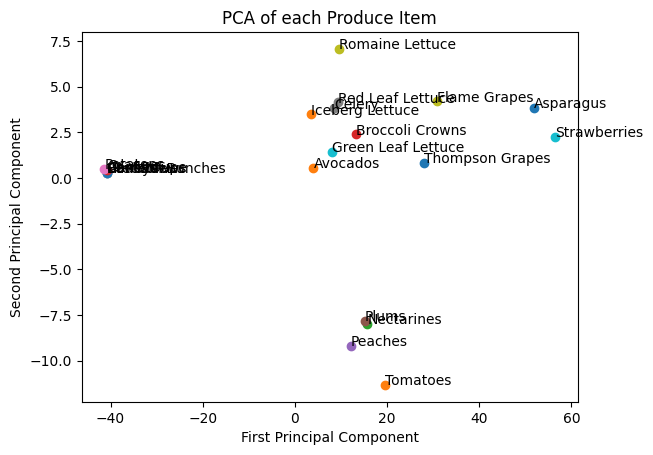

In [12]:
pca3 = PCA(2)
xhat3 = pca3.fit_transform(detrended_price_data)
plt.title("PCA of each Produce Item")
for x, label in zip(xhat3, products):
    plt.scatter(x[0], x[1])
    plt.annotate(label, (x[0], x[1]), fontsize=10)
plt.xlabel("First Principal Component")
plt.ylabel("Second Principal Component")

In [13]:
pca = PCA(2)

In [16]:
xhat = pca.fit_transform(data_prices)


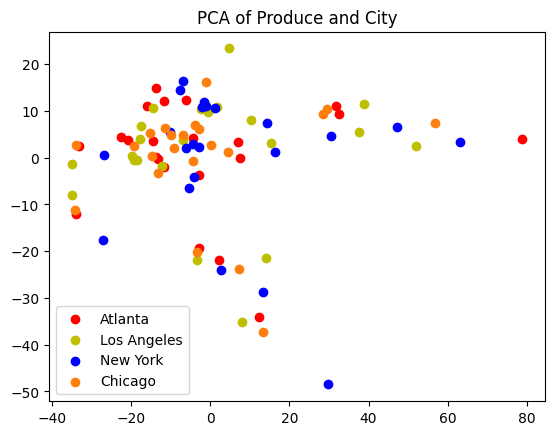

In [25]:
plt.title("PCA of Produce and City")
plt.scatter(xhat[mask1, 0], xhat[mask1, 1], c='r', label="Atlanta")
plt.scatter(xhat[mask2, 0], xhat[mask2, 1], c='y', label="Los Angeles")
plt.scatter(xhat[mask3, 0], xhat[mask3, 1], c='b', label="New York")
plt.scatter(xhat[mask4, 0], xhat[mask4, 1], c='tab:orange', label="Chicago")

plt.legend()
plt.show()

In [7]:
pca2 = PCA(2)
xhat2 = pca2.fit_transform(detrended_price_data.T)

1019
(1018, 2)


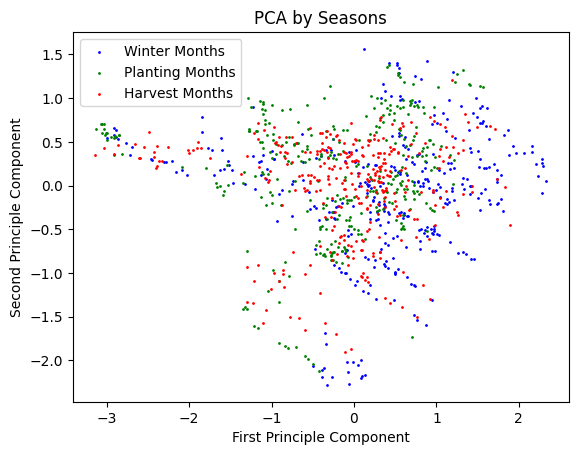

In [11]:
mask1 = (month_labels == 1) | (month_labels == 2) | (month_labels == 3) | (month_labels == 12)
mask2 = (month_labels == 4) | (month_labels == 5) | (month_labels == 6) | (month_labels == 7)
mask3 = (month_labels == 8) | (month_labels == 9) | (month_labels == 10) | (month_labels == 11)
print(len(mask1))
print(xhat2.shape)
plt.title("PCA by Seasons")
plt.xlabel("First Principle Component")
plt.ylabel("Second Principle Component")
plt.scatter(xhat2[mask1[:-1], 0], xhat2[mask1[:-1], 1], c='b', s=1, label="Winter Months")
plt.scatter(xhat2[mask2[:-1], 0], xhat2[mask2[:-1], 1], c='g', s=1, label="Planting Months")
plt.scatter(xhat2[mask3[:-1], 0], xhat2[mask3[:-1], 1], c='r', s=1, label="Harvest Months")
# plt.scatter(xhat[mask2, 0], xhat[mask2, 1], c=2, s=1, label=2)
# plt.scatter(xhat[mask3, 0], xhat[mask3, 1], c=3, s=1, label=3)
# plt.scatter(xhat[mask4, 0], xhat[mask4, 1], c=4, s=1, label=4)
# plt.scatter(xhat[mask5, 0], xhat[mask5, 1], c=5, s=1, label=5)
# plt.scatter(xhat[mask6, 0], xhat[mask6, 1], c=6, s=1, label=6)
# plt.scatter(xhat[mask7, 0], xhat[mask7, 1], c=7, s=1, label=7)
# plt.scatter(xhat[mask8, 0], xhat[mask8, 1], c=8, s=1, label=8)
# plt.scatter(xhat[mask9, 0], xhat[mask9, 1], c=9, s=1, label=9)
# plt.scatter(xhat[mask10, 0], xhat[mask10, 1], c=10, s=1, label=10)
# plt.scatter(xhat[mask11, 0], xhat[mask11, 1], c=11, s=1, label=11)
# plt.scatter(xhat[mask12, 0], xhat[mask12, 1], c=12, s=1, label=12)
plt.legend()
plt.show()